In [14]:
import sys  
sys.path.insert(1, 'D:/KINEPY/new 22.02.2025/kinepy-dev/kinepy-dev')
import kinepy as kp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

https://www.desmos.com/calculator/vy8nrrrqpm?lang=fr

In [17]:
train_mass = 400000 # kg
train_lenght = 200 # m

train_linear_density = train_mass/train_lenght # kg/m

deck_linear_density = 10000 # kg/m
top_bottom_linear_density = 700 # kg/m
diagonal_linear_density = 500 # kg/m

bridge_height = 13.55 # m
bridge_lenght = 68 # m
nb_sections = 9

bottom_beam_lenght = bridge_lenght/nb_sections # m

In [21]:
bottom_points = np.array([np.linspace(-bridge_lenght/2, bridge_lenght/2, nb_sections+1), 
                          np.zeros(nb_sections+1)])

bridge_shape_fonction = lambda x, bridge_const : bridge_height + bridge_const*(1 - np.cosh(x/bridge_const))
bridge_const = brentq(lambda c : bridge_shape_fonction(bridge_lenght/2, c), 10, 1e3, xtol=1e-8, maxiter=100)

x = np.linspace(-(nb_sections-1)*bottom_beam_lenght/2, (nb_sections-1)*bottom_beam_lenght/2, nb_sections)
top_points = np.array([x, bridge_shape_fonction(x, bridge_const)])

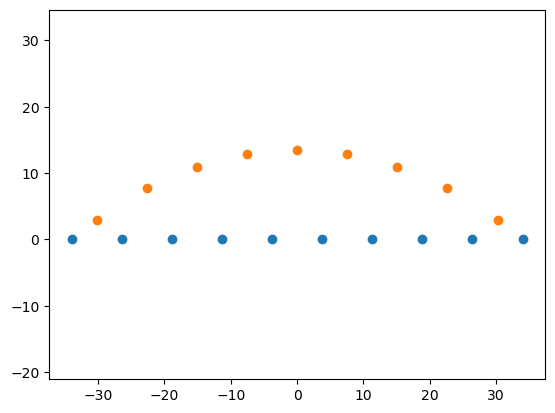

In [23]:
plt.plot(bottom_points[0], bottom_points[1], 'o')
plt.plot(top_points[0], top_points[1], 'o')
plt.axis('equal')
plt.show()

In [110]:
bridge = kp.System()

ground = bridge.ground

norm = np.linalg.norm

bottom_beams = []
top_beams = []
diagonal_beams = []

top_revolutes = []
left_revolutes = []
right_revolutes = []

# bottom triangles
for triangle_index in range(nb_sections):
    v1, v2 = bottom_points.T[triangle_index:][:2] - top_points[:, triangle_index]
    left_diagonal_lenght = norm(v1)
    right_diagonal_lenght = norm(v2)

    bottom_mass = top_bottom_linear_density*bottom_beam_lenght
    right_diagonal_mass = diagonal_linear_density*right_diagonal_lenght

    if triangle_index in [0, nb_sections - 1]:
        left_diagonal_mass = top_bottom_linear_density*left_diagonal_lenght
    else:
        left_diagonal_mass = diagonal_linear_density*left_diagonal_lenght
    
    bottom_beam = bridge.add_solid(mass=bottom_mass, g=(bottom_beam_lenght/2, 0))
    left_beam = bridge.add_solid(mass=left_diagonal_mass, g=(left_diagonal_lenght/2, 0))
    right_beam = bridge.add_solid(mass=right_diagonal_mass, g=(right_diagonal_lenght/2, 0))
    
    r0 = bridge.add_revolute(bottom_beam, left_beam)
    r1 = bridge.add_revolute(bottom_beam, right_beam, p1=(bottom_beam_lenght, 0))
    r2 = bridge.add_revolute(left_beam, right_beam, p1=(left_diagonal_lenght, 0), p2=(right_diagonal_lenght, 0))
    
    bridge.declare_direct_triangle(r0, r1, r2)
    
    bottom_beams.append(bottom_beam)
    if triangle_index == 0:
        top_beams.append(left_beam)
    else:
        diagonal_beams.append(left_beam)

    if triangle_index == nb_sections - 1:
        top_beams.append(right_beam)
    else:
        diagonal_beams.append(right_beam)

    left_revolutes.append(r0)
    right_revolutes.append(r1)
    top_revolutes.append(r2)

# top triangles
for triangle_index in range(nb_sections-1):
    v1 = top_points[:, triangle_index] - top_points[:, triangle_index+1]
    top_beam_lehght = norm(v1)

    top_mass = top_bottom_linear_density*top_beam_lehght
    
    top_beam = bridge.add_solid(mass=top_mass, g=(top_beam_lehght/2, 0))
    
    _r1, _r2 = top_revolutes[triangle_index:][:2]
    b3, b4 = bottom_beams[triangle_index:][:2]
    
    r0 = bridge.add_revolute(b3, b4, p1=(bottom_beam_lenght, 0))
    r1 = bridge.add_revolute(top_beam, _r1.s1, p2=_r1.p1)
    r2 = bridge.add_revolute(top_beam, _r2.s2, p1=(top_beam_lehght, 0), p2=_r2.p2)
    
    bridge.declare_direct_triangle(r0, r2, r1)
    top_beams.append(top_beam)

# edge joints
bridge.add_revolute(bottom_beams[0], ground, p2=(-bridge_lenght/2, 0))
ps = bridge.add_pin_slot(bottom_beams[-1], ground, p2=(bridge_lenght/2, 0))
#bridge.declare_chose_lowest_value(ps.sliding)

gravity = bridge.add_gravity(g=(0, -10))

# deck and train force
left_beam_forces, right_beams_forces = [], []
for bottom_beam in bottom_beams:
    left_beam_forces.append(bridge.add_action(bottom_beam, (0, 0)))
    right_beams_forces.append(bridge.add_action(bottom_beam, (bottom_beam_lenght, 0)))

bridge.determine_computation_order()
n = 3
bridge.set_sim_parameters(n, 3)

# deck and train force
deck_train_mass = bottom_beam_lenght/2*(deck_linear_density + train_linear_density)
for left_beam_force, right_beam_force in zip(left_beam_forces, right_beams_forces):
    left_beam_force.set_force(gravity.g*deck_train_mass)
    right_beam_force.set_force(gravity.g*deck_train_mass)


In [112]:
bridge.solve_kinematics()

In [114]:
kd = bridge.kinematic_diagram()
kd.show()

In [116]:
bridge.solve_dynamics()

((0,), (1, 2, 3, 4, 5, 6, 28, 7, 8, 9, 29, 10, 11, 12, 30, 13, 14, 15, 31, 16, 17, 18, 32, 19, 20, 21, 33, 22, 23, 24, 34, 25, 26, 27, 35), (36,)) (1, 2, 3, 4, 5, 6, 28, 7, 8, 9, 29, 10, 11, 12, 30, 13, 14, 15, 31, 16, 17, 18, 32, 19, 20, 21, 33, 22, 23, 24, 34, 25, 26, 27, 35) -1.0


In [119]:
for left_revolute, right_revolute in zip(left_revolutes[1:], right_revolutes[:-1]):
    print(left_revolute.get_force()[0])
    print(right_revolute.get_force()[0])
    print()

[ -511476.09818213 -1019138.72098027]
[1099948.53689444 -847083.50124194]

[-295397.25638307 -829097.95073442]
[  520316.80234713 -1037124.27148779]

[-250486.38232235 -822412.15231608]
[  369309.8098038  -1043810.06990616]

[-257534.86183405 -888550.02025584]
[ 295917.00685102 -977672.20196637]

[-295597.78613825 -976581.25892461]
[ 257839.01979567 -889640.96329762]

[ -368853.94020552 -1042485.7924596 ]
[ 250873.87898733 -823736.42976262]

[ -519331.79589608 -1035120.3719177 ]
[ 296087.07927055 -831101.85030452]

[-1100471.80592478  -842698.75791884]
[  513631.39604431 -1023523.46430338]

